## Plotting a range of PDFs vertical distributions of eatin gand precip from TRBELT simulations

In [3]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as mp
from matplotlib import cm
from matplotlib.colors import ListedColormap

import os
import glob as gb

from dask.distributed import Client
from ncar_jobqueue import NCARCluster

In [4]:
cluster = NCARCluster(project='P93300642',interface='mgt', job_extra_directives=[])
cluster
cluster.scale(jobs=8)
client = Client(cluster)
client

/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, Future

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.18.206.54:38535,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [36]:
dir0 = '/glade/derecho/scratch/rneale/archive/'


#### RUN INFO ####

cases = ['CAM7','+KE','+KE(TKE)','+dmpdz(1e-4)']
runs = ['f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a','f.cam6_4_032.FLTHIST_ne30.cam7_ke.002b','f.cam6_4_032.FLTHIST_ne30.cam7_ke.008b','f.cam6_4_032.FLTHIST_ne30.cam7_ke.004b']
#runs = ['f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a','f.cam6_4_032.FLTHIST_ne30.cam7_ke.005b','f.cam6_4_032.FLTHIST_ne30.cam7_ke.006b','f.cam6_4_032.FLTHIST_ne30.cam7_ke.008b']
 

#### REGIONS ###

reg_name = "Tropics" ; lat_lims = [-15,15]  ; lon_lims = [120,150]
#reg_name = "Monsoon Pacific" ; lat_lims = [15,50]  ; lon_lims = [120,150]

period = '200?-01' ; period_name = 'January'
#period = '200?-07' ; period_name = 'July'
#period = '000?-04' ; period_name = 'April'

ldiff = True


#### Model Data Frequency ####

channel = 'h0a' ; cfreq = 'monthly' # Frequency=monthly or daily
#channel = 'h1a' ; cfreq = 'daily' # Frequency=monthly or daily


#### 3D Dependent variable ####

#var_3d = 'DTCOND'  ;  v3d_units = 'K/day' ; v3d_scale = 86400. ; clev_scale = [1.5,0.4] ; clev_offset = [0.,0.] ; cont_cbar = ['RdBu_r','RdBu_r']
#var_3d = 'ZMDT'  ;  v3d_units = 'K/day' ; v3d_scale = 86400. ; clev_scale = [1,0.5] ; clev_offset = [0.,0.] ; cont_cbar = ['RdBu_r','RdBu_r']
#var_3d = 'ZMDQ'  ;  v3d_units = 'g/kg/day' ; v3d_scale = 1000.*86400. ; clev_scale = [0.5,0.25] ; clev_offset = [0.,0.] ; cont_cbar = ['RdBu_r','RdBu_r']
#var_3d = 'ZMMU'  ;  v3d_units = 'kg/m^2/hr' ; v3d_scale = 3600. ; clev_scale = [4.,2.5] ; clev_offset = [10.,0.] ; cont_cbar = ['Purples','PuOr']
#var_3d = 'ZMMD'  ;  v3d_units = 'kg/m^2/hr' ; v3d_scale = 3600. ; clev_scale = [0.5,0.25] ; clev_offset = [-10.,0.] ; cont_cbar = ['Purples_r','PuOr']

#var_3d = 'KEPAR'  ;  v3d_units = 'J/kg' ; v3d_scale = 1. ; clev_scale = [5,5] ; clev_offset = [0.,0.] ; cont_cbar = ['RdBu_r','RdBu_r']

#var_3d = 'BUOY'  ;  v3d_units = 'K' ; v3d_scale = 1. ; clev_scale = [0.1,0.1] ; clev_offset = [0.,0.] ; cont_cbar = ['RdBu_r','RdBu_r']

var_3d = 'STEND_CLUBB'  ;  v3d_units = 'K/day' ; v3d_scale = 86400./1000. ; clev_scale = [0.5,0.25] ; clev_offset = [0.,0.] ; cont_cbar = ['RdBu_r','RdBu_r']
#var_3d = 'RELHUM'  ;  v3d_units = '%'     ; v3d_scale = 1. ; clev_scale = [5.,2.] ; clev_offset = [10.,0.] ; cont_cbar = ['Purples','PuOr']



#### 2D Independent Variable ####

var_2d = 'PRECT'   ;  v2d_units = 'mm/day' ; v2d_scale = 86400.*1000.
#var_2d = 'PRECC'   ;  v2d_units = 'mm/day' ; v2d_scale = 86400.*1000.


/glade/derecho/scratch/rneale/tmp/ipykernel_10370/2606075107.py:8: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.4)



---- X 2D variable = PRECT ----
---- X,Y 3D variable = STEND_CLUBB ----
---- Calculating differences is  True  ----
---- Data Frequency is = monthly ----
---- Location (lat/lon) = Tropics_(15S-15N : 120E-150E)



---- CASE = CAM7 ----
/glade/derecho/scratch/rneale/archive/f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a/atm/hist/f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a.cam.h0a.200?-01*nc
First = /glade/derecho/scratch/rneale/archive/f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a/atm/hist/f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a.cam.h0a.2000-01.nc
Last  = /glade/derecho/scratch/rneale/archive/f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a/atm/hist/f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a.cam.h0a.2006-01.nc
          ibin,binmin,binmax,cum %age ==  0 0.1 0.5 14.82514880952381
          ibin,binmin,binmax,cum %age ==  1 0.5 1 9.078931051587302
          ibin,binmin,binmax,cum %age ==  2 1 1.5 5.970982142857143
          ibin,binmin,binmax,cum %age ==  3 1.5 2 4.9851190476190474
          ibin,binmin,binmax,cum %age == 

/glade/derecho/scratch/rneale/tmp/ipykernel_10370/2606075107.py:132: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_mod = cm.get_cmap(cmap)


          ibin,binmin,binmax,cum %age ==  0 0.1 0.5 13.45486111111111
          ibin,binmin,binmax,cum %age ==  1 0.5 1 7.576884920634921
          ibin,binmin,binmax,cum %age ==  2 1 1.5 5.462549603174603
          ibin,binmin,binmax,cum %age ==  3 1.5 2 4.701450892857143
          ibin,binmin,binmax,cum %age ==  4 2 2.5 4.642547123015873
          ibin,binmin,binmax,cum %age ==  5 2.5 3 4.239521329365079
          ibin,binmin,binmax,cum %age ==  6 3 3.5 3.7744915674603177
          ibin,binmin,binmax,cum %age ==  7 3.5 4 3.673735119047619
          ibin,binmin,binmax,cum %age ==  8 4 4.5 3.5636780753968256
          ibin,binmin,binmax,cum %age ==  9 4.5 5 3.283110119047619
          ibin,binmin,binmax,cum %age ==  10 5 6 6.019035218253968
          ibin,binmin,binmax,cum %age ==  11 6 7 5.535404265873016
          ibin,binmin,binmax,cum %age ==  12 7 8 4.727802579365079
          ibin,binmin,binmax,cum %age ==  13 8 9 3.816344246031746
          ibin,binmin,binmax,cum %age ==  14 9 1

/glade/derecho/scratch/rneale/tmp/ipykernel_10370/2606075107.py:132: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_mod = cm.get_cmap(cmap)


          ibin,binmin,binmax,cum %age ==  0 0.1 0.5 13.772631448412698
          ibin,binmin,binmax,cum %age ==  1 0.5 1 7.395523313492063
          ibin,binmin,binmax,cum %age ==  2 1 1.5 5.414496527777778
          ibin,binmin,binmax,cum %age ==  3 1.5 2 4.6673487103174605
          ibin,binmin,binmax,cum %age ==  4 2 2.5 4.344928075396825
          ibin,binmin,binmax,cum %age ==  5 2.5 3 3.8519965277777777
          ibin,binmin,binmax,cum %age ==  6 3 3.5 3.6628844246031744
          ibin,binmin,binmax,cum %age ==  7 3.5 4 3.515625
          ibin,binmin,binmax,cum %age ==  8 4 4.5 3.4117683531746033
          ibin,binmin,binmax,cum %age ==  9 4.5 5 3.1312003968253967
          ibin,binmin,binmax,cum %age ==  10 5 6 6.000434027777778
          ibin,binmin,binmax,cum %age ==  11 6 7 5.222284226190476
          ibin,binmin,binmax,cum %age ==  12 7 8 4.664248511904762
          ibin,binmin,binmax,cum %age ==  13 8 9 3.9543030753968256
          ibin,binmin,binmax,cum %age ==  14 9 10 3.

/glade/derecho/scratch/rneale/tmp/ipykernel_10370/2606075107.py:132: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_mod = cm.get_cmap(cmap)


          ibin,binmin,binmax,cum %age ==  0 0.1 0.5 11.583116319444445
          ibin,binmin,binmax,cum %age ==  1 0.5 1 6.957103587962963
          ibin,binmin,binmax,cum %age ==  2 1 1.5 5.197482638888889
          ibin,binmin,binmax,cum %age ==  3 1.5 2 4.4921875
          ibin,binmin,binmax,cum %age ==  4 2 2.5 3.984013310185185
          ibin,binmin,binmax,cum %age ==  5 2.5 3 3.593388310185185
          ibin,binmin,binmax,cum %age ==  6 3 3.5 3.4107349537037037
          ibin,binmin,binmax,cum %age ==  7 3.5 4 3.443287037037037
          ibin,binmin,binmax,cum %age ==  8 4 4.5 3.2606336805555554
          ibin,binmin,binmax,cum %age ==  9 4.5 5 3.416160300925926
          ibin,binmin,binmax,cum %age ==  10 5 6 6.438078703703703
          ibin,binmin,binmax,cum %age ==  11 6 7 6.340422453703703
          ibin,binmin,binmax,cum %age ==  12 7 8 5.416304976851852
          ibin,binmin,binmax,cum %age ==  13 8 9 4.879195601851852
          ibin,binmin,binmax,cum %age ==  14 9 10 3.967

/glade/derecho/scratch/rneale/tmp/ipykernel_10370/2606075107.py:132: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_mod = cm.get_cmap(cmap)


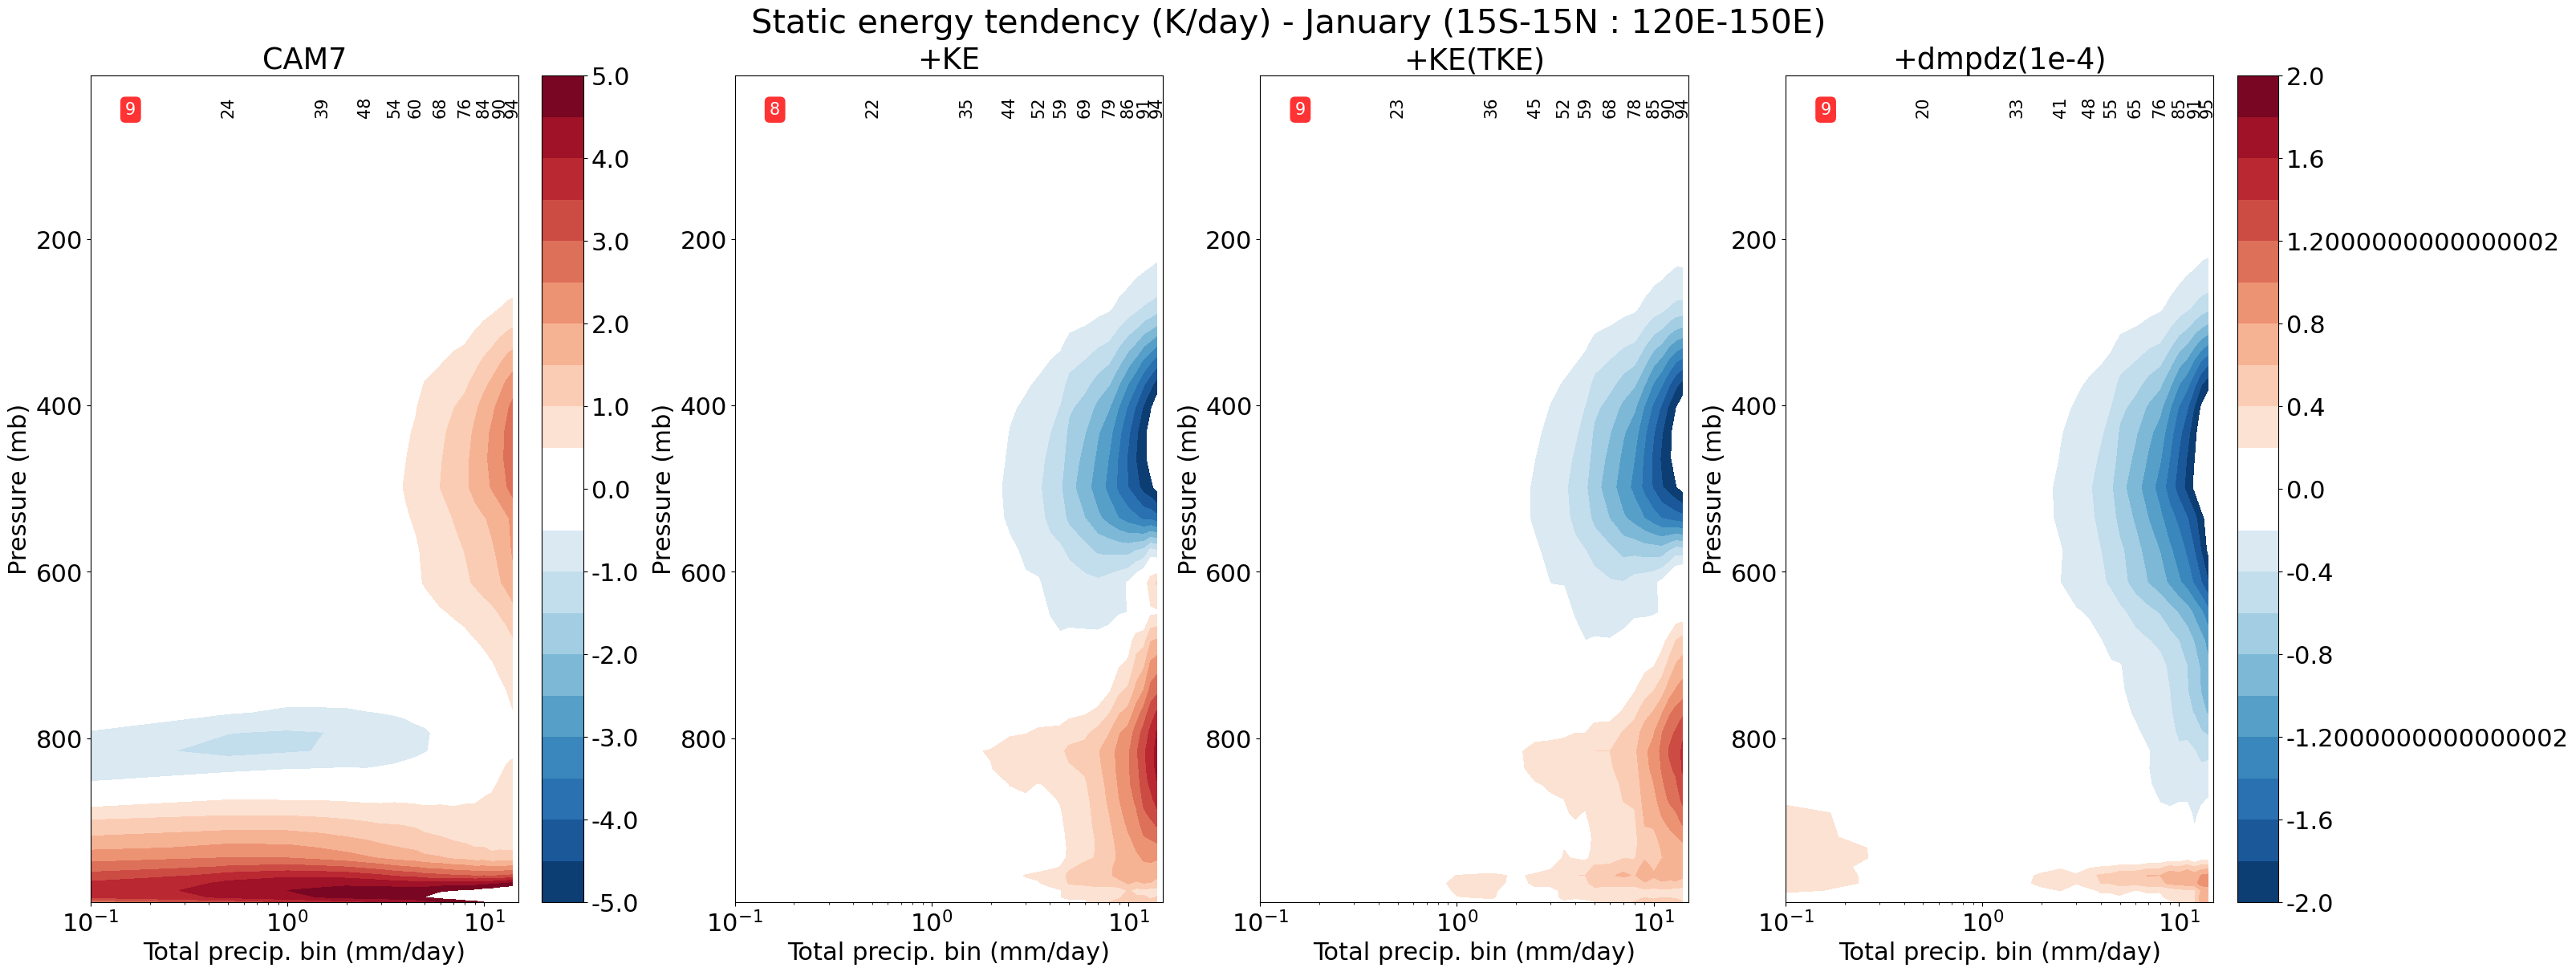

In [37]:
# Directories
dir_fig  = '/glade/u/home/rneale/python/python-figs/zm_dev/'


# Set up figure variables 
ncases = len(cases)
plt, ax1 = mp.subplots(1, ncases, figsize=(32,12), constrained_layout=True)
plt.subplots_adjust(wspace=0.4) 

cb_skip = 2

if var_2d in ['PRECC','PRECT']:
#    bins_x = [0.1,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,20,25,30,50]
    bins_x = [0.1,0.5,1,1.5,2,2.5,3,3.5,4,4.5,5,6,7,8,9,10,11,12,13,14,15]


clevels0 = [-10.,-9.,-8.,-7.,-6.,-5.,-4.,-3.,-2.,-1.,0.,1.,2.,3.,4.,5.,6.,7.,8.,9.,10.]



yname = 'Pressure (mb)'

reg_dom  = '('+str(abs(lat_lims[0]))+'N-' if lat_lims[0] >= 0 else '('+str(abs(lat_lims[0]))+'S-'
reg_dom += str(abs(lat_lims[1]))+'N : ' if lat_lims[1] >= 0 else str(abs(lat_lims[0]))+'S : '

if (ll >0 for ll in lat_lims):
    reg_dom += str(abs(lon_lims[0]))+'E-'
    reg_dom += str(abs(lon_lims[1]))+'E)'


#Construct lat/lon name



print('')
print('---- X 2D variable = '+var_2d+ ' ----')
print('---- X,Y 3D variable = '+var_3d+ ' ----')
print('---- Calculating differences is ',ldiff,' ----')
print('---- Data Frequency is = '+cfreq+ ' ----')
print('---- Location (lat/lon) = '+reg_name+'_'+reg_dom)
print('')
print('')

# Loop cases

for it,trun in enumerate(runs):


    dir_in = dir0+trun+'/atm/hist/'
    print('')
    print('---- CASE = '+cases[it]+ ' ----')

    print(dir_in+trun+'.cam.'+channel+'.'+period+'*nc')
    fhist_h = sorted(gb.glob(dir_in+trun+'.cam.'+channel+'.'+period+'*nc'))
    print('First = '+fhist_h[0])
    print('Last  = '+fhist_h[-1])
    
#    run_path = dir0+trun+'.cam.h0.'+yr_mn+'.nc'
    ds_case = xr.open_mfdataset(fhist_h,parallel=True)   
    ds_case = ds_case.sel(lat=slice(lat_lims[0],lat_lims[1]))
    
    da_3d_var = ds_case[var_3d]

  
    
    if var_2d == 'PRECT':
        da_2d_var = ds_case['PRECC']+ds_case['PRECL'] ; xname = 'Total precip. bin (mm/day)'
    else:
        da_2d_var = ds_case[var_2d] ; xname = 'Convective precip. bin (mm/day)'
    
    
    da_2d_var = da_2d_var.compute()*v2d_scale
    da_3d_var = da_3d_var.compute()*v3d_scale
    
    # New plot array creation (with zeros)
    xy_cond = xr.zeros_like(da_2d_var)
    xyp_cond = xr.zeros_like(da_3d_var)
   
    # Set up plot array
    coords = {'lev':da_3d_var.lev.values,'bin':bins_x}
    da_plot_var = xr.DataArray(data=np.full((len(da_3d_var.lev.values),len(bins_x)),np.nan),coords=coords,dims=['lev','bin']) 

    # Unroll input array
    da_3d_var_timelatlon = da_3d_var.stack(time_lat_lon=("time", "lat", "lon"))  
 
    gps_total = da_2d_var.size
    
    # Loop bins to construct averaged profile

    pcent_bin = []

    # Percentage below the lowest bin level
    xy_cond.values = np.logical_and(da_2d_var>=0, da_2d_var<bins_x[0])
    gps_bin0 = xy_cond.values.sum()
    pcent_zero = 100.*gps_bin0/gps_total
    
    
    for ix in range(0,len(bins_x[:-1])):
 
        xy_cond.values = np.logical_and(da_2d_var>=bins_x[ix], da_2d_var<bins_x[ix+1])

        gps_bin = xy_cond.values.sum()
        pcent_bin.append(100.*gps_bin/gps_total)
                                                                                                    
        print('          ibin,binmin,binmax,cum %age == ',ix,bins_x[ix],bins_x[ix+1],pcent_bin[ix])
        
        xy_cond_timelatlon = xy_cond.stack(time_lat_lon=("time", "lat", "lon")) # Flatten to 1D array
        
        da_plot_var[:,ix] = da_3d_var_timelatlon[:,xy_cond_timelatlon].mean(dim=["time_lat_lon"])
      
    
    
    if it == 0: 
        da_plot_save = da_plot_var
        icont_opt = 0
    
    if it > 0 and ldiff:
        da_plot_var = da_plot_var-da_plot_save
        icont_opt = 1
        
    clevels = [x+clev_offset[icont_opt] for x in clevels0]
    clevels = [x*clev_scale[icont_opt] for x in clevels]
  

# Knowing clevels we can see if we need to modify color map to get white next zero

    cmap = cont_cbar[1] if ldiff and it>0 else cont_cbar[0]
 
    
    
# Modify colorbars to be white in the middle or white at the start
    cmap_mod = cm.get_cmap(cmap)
    
# Convert it to a ListedColormap so we can modify it
    cmap_colors = cmap_mod(np.linspace(0, 1, 256))

    if min(clevels) < 0 and max(clevels) > 0:    

# Make a "white band" around zero (e.g., indices 120 to 136)
        cmap_colors[120:136, :] = [1, 1, 1, 1]  # RGBA = white

    else:

        if var_3d in ['ZMMD']: #For -ve value variables
# Make a "white band" at the start of the colorbar
            
            cmap_colors[248:256,:] = [1, 1, 1, 1]  # RGBA = white
        else:
        
            cmap_colors[0:8,:] = [1, 1, 1, 1]  # RGBA = white

   # Create a new colormap with the white band inserted
    cmap_it = ListedColormap(cmap_colors)




    
    pcent_cumu = np.cumsum(pcent_bin)


# This helps mask out low pressure values.
    xx, yy = np.meshgrid(bins_x, da_plot_var.lev)
    da_plot_var_mask = np.ma.masked_where(yy < 75, da_plot_var)
    
    plt = ax1[it].contourf(bins_x,da_plot_var.lev,da_plot_var_mask,levels=clevels,cmap=cmap_it) 
    ax1[it].set_xscale('log')

# Add text about fraction of gridpoints to the plot.

    ax1[it].text(bins_x[0]+0.1*(bins_x[1]+bins_x[0]), 50.,f"{pcent_zero:.0f}", color="w", fontsize=15, ha='center',bbox=dict(
        boxstyle='round,pad=0.3', 
        facecolor='red',   # Background color
        edgecolor='none',   # Optional: no border
        alpha=0.8           # Optional: slight transparency
    ))
    for ii in range(0,len(bins_x[:-1]),2):
        ax1[it].text(bins_x[ii+1], 50.,f"{pcent_cumu[ii]+pcent_zero:.0f}", color="k", fontsize=15, ha='center', rotation=90.)
        
    
    if it == 0 and ldiff: 
        cbar = mp.colorbar(plt,ax=ax1[it])
        cbar.set_ticks(clevels[::cb_skip])
        cbar.set_ticklabels([str(t) for t in clevels[::cb_skip]])  # Option
    
    if it == ncases-1 : 
        cbar = mp.colorbar(plt,ax=ax1[it]) 
        cbar.set_ticks(clevels[::cb_skip])
        cbar.set_ticklabels([str(t) for t in clevels[::cb_skip]])  # Option

    
    
    ax1[it].set_title(cases[it])
    ax1[it].set_ylabel(yname)  ; ax1[it].invert_yaxis()  
    ax1[it].set_xlabel(xname)

# Final fig stuff

mp.suptitle(ds_case[var_3d].attrs['long_name']+' ('+v3d_units+') - '+period_name+' '+reg_dom , fontsize=30)
mp.rcParams.update({'font.size': 22})


tdiff = 'anoms' if ldiff else '' 
mp.savefig(dir_fig+'zm_all_ke_'+var_3d+'_'+var_2d+'_'+period_name+'_'+cfreq+'_'+reg_name+'_'+tdiff+'_binned_profiles.png', dpi=75)